# 
Partie 1 – Graphique linéaire (Line Plot) 
1) Afficher l'évolution de la température en fonction du temps, avec le titre, les labels, la légende et la grille.
2) Identifier visuellement les valeurs qui semblent anormales. 

In [1]:
# charger les bibliothèques nécessaires
import matplotlib.pyplot as plt
import pandas as pd

In [9]:
#charger les données depuis le fichier CSV
df = pd.read_csv('../data/mesures_capteurs.csv')
df.head()

,id_mesure,date_heure,id_capteur,batiment,temperature,humidite,pression,consommation,etat
0,M0413,2026-01-22 04:00:00,C005,B002,25.46,58.06,1008.95,287.28,OK
1,M0290,2026-01-17 01:00:00,C002,B001,24.00,79.73,993.39,116.20,OK
2,M0077,2026-01-08 04:00:00,C005,B002,25.82,54.47,1010.32,288.50,OK
3,M0079,2026-01-08 06:00:00,C007,B003,28.23,69.39,1019.62,136.65,OK
4,M0183,2026-01-12 14:00:00,C003,B001,20.58,53.80,1016.58,182.62,OK


In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 605 entries, 0 to 604
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   id_mesure     605 non-null    object 
 1   date_heure    605 non-null    object 
 2   id_capteur    605 non-null    object 
 3   batiment      605 non-null    object 
 4   temperature   599 non-null    float64
 5   humidite      600 non-null    float64
 6   pression      600 non-null    float64
 7   consommation  600 non-null    float64
 8   etat          601 non-null    object 
dtypes: float64(4), object(5)
memory usage: 42.7+ KB


In [12]:
#convertire la colonne date-heure en format datetime
#data['date-heure'] = pd.to_datetime(data['date-heure'])
df["date_heure"] = pd.to_datetime(df["date_heure"])


In [16]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 605 entries, 0 to 604
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   id_mesure     605 non-null    object        
 1   date_heure    605 non-null    datetime64[ns]
 2   id_capteur    605 non-null    object        
 3   batiment      605 non-null    object        
 4   temperature   599 non-null    float64       
 5   humidite      600 non-null    float64       
 6   pression      600 non-null    float64       
 7   consommation  600 non-null    float64       
 8   etat          601 non-null    object        
dtypes: datetime64[ns](1), float64(4), object(4)
memory usage: 42.7+ KB


In [18]:
#trier les ligne suivant la  chronologie pour suivre laffichage dans le temps 
df = df.sort_values(by="date_heure")
df.head()

,id_mesure,date_heure,id_capteur,batiment,temperature,humidite,pression,consommation,etat
150,M0001,2026-01-05 00:00:00,C001,B001,24.91,54.60,1019.00,222.33,OK
547,M0002,2026-01-05 01:00:00,C002,B001,18.15,51.98,1014.02,165.77,OK
20,M0003,2026-01-05 02:00:00,C003,B001,23.95,56.47,1020.04,215.00,OK
282,M0004,2026-01-05 03:00:00,C004,B002,26.20,76.27,1016.74,191.33,OK
484,M0005,2026-01-05 04:00:00,C005,B002,27.11,55.41,1020.03,227.75,OK


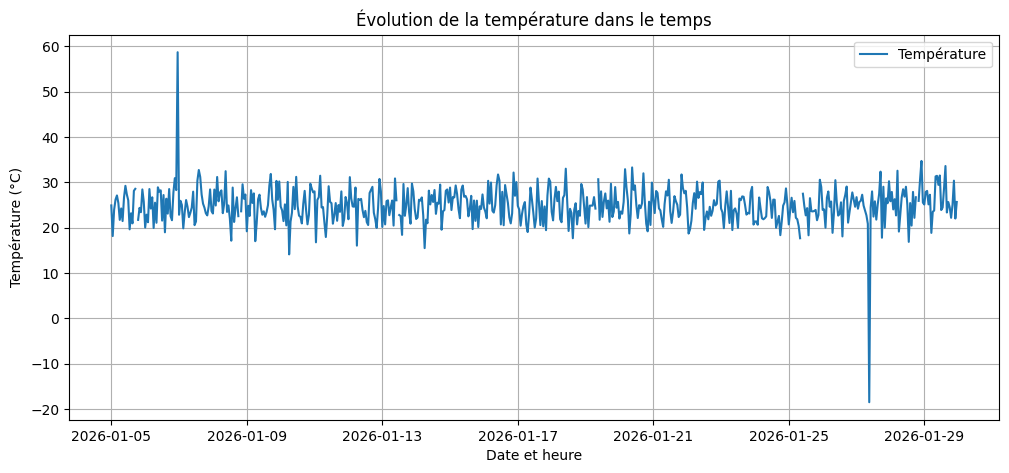

In [19]:
#1) Afficher l'évolution de la température en fonction du temps, avec le titre, les labels, la légende et la grille.
plt.figure(figsize=(12, 5))
plt.plot(df["date_heure"], df["temperature"], label="Température")

plt.title("Évolution de la température dans le temps")
plt.xlabel("Date et heure")
plt.ylabel("Température (°C)")
plt.legend()
plt.grid(True)

plt.show()

##2) Identifier visuellement les valeurs qui semblent anormales. 


On observe deux anomalies très nettes sur la courbe : un pic autour du 6-7 janvier 
atteignant environ 58-60°C, et une chute autour du 27-28 janvier descendant à 
environ -20°C. Ces deux valeurs sont totalement incohérentes avec le comportement 
normal des données (qui oscillent entre 15 et 30°C) et apparaissent de façon isolée, 
ce qui suggère des erreurs de mesure plutôt que de vraies variations climatiques.